Loading data from dataset/joined/joined_user_order_counts.csv...
Preprocessing data types...

[2] Buyer Analysis (Excluding Window Shoppers)
Total Buyers (Unique): 80,044
  - One-time Buyers: 49,832
  - Repurchasers: 30,212


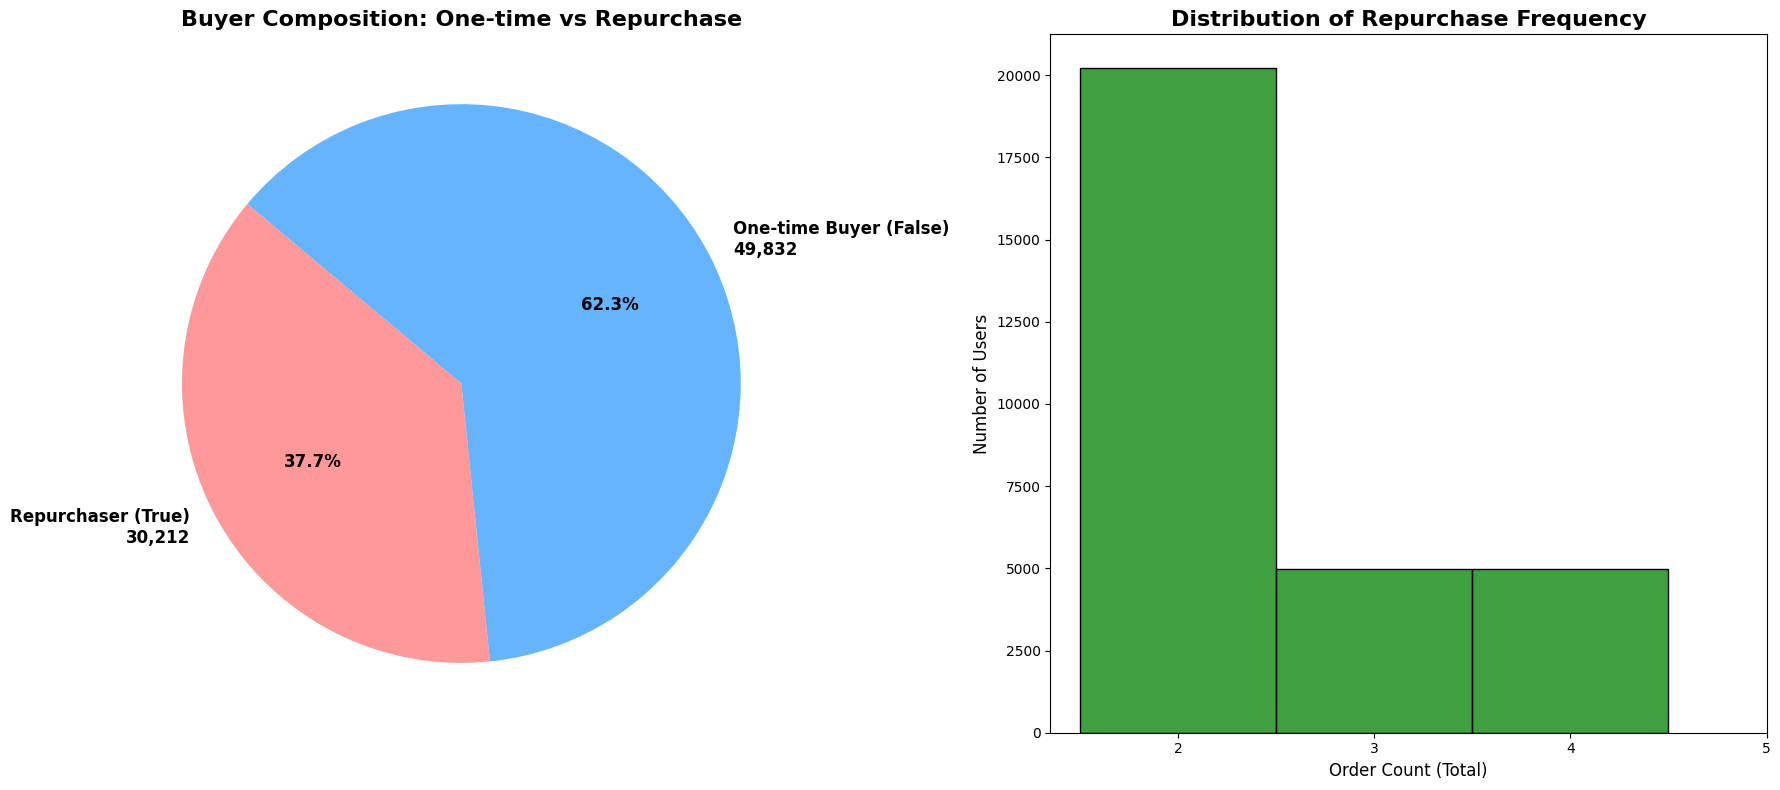


[3] Activity & Revenue Analysis


/var/folders/1g/n3wk5qts0l7484gylwvq_jkm0000gn/T/ipykernel_34530/3399410269.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='has_repurchase', y='sale_price', data=filtered_prices, palette='coolwarm', showfliers=False)
/var/folders/1g/n3wk5qts0l7484gylwvq_jkm0000gn/T/ipykernel_34530/3399410269.py:113: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('buyer_count')
/var/folders/1g/n3wk5qts0l7484gylwvq_jkm0000gn/T/ipykernel_34530/3399410269.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='repurchase_rate', y='traffic_source', data=traffic_stats, palette='viridis')


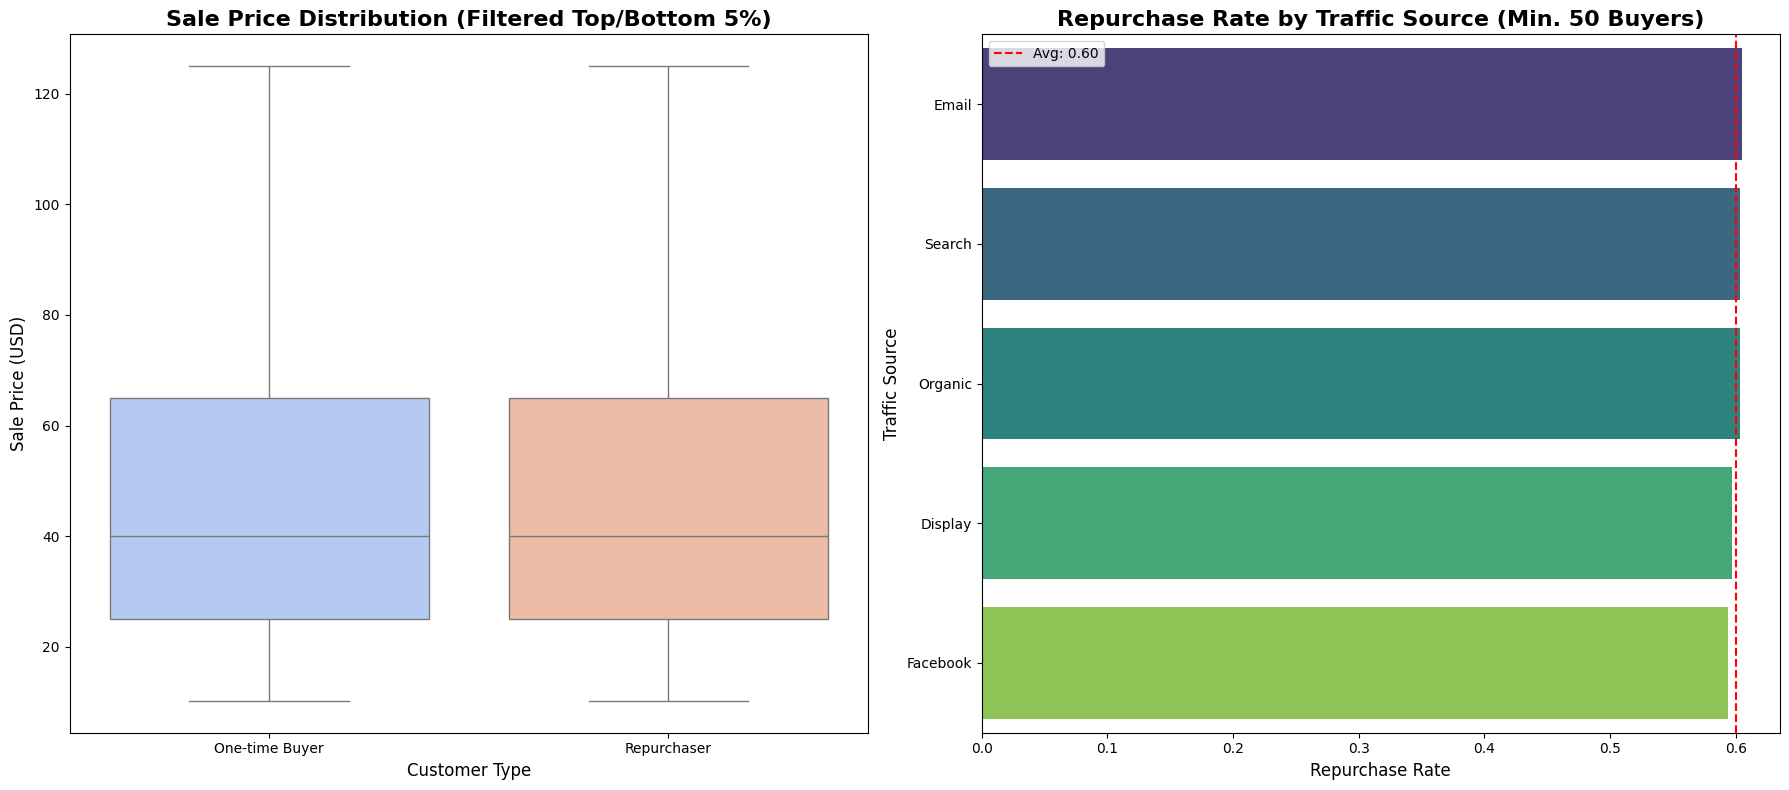


📊 FINAL SUMMARY REPORT
1. Overall Repurchase Rate: 37.74%
   (Out of 80,044 buyers, 30,212 returned)
2. Best Channel for Loyalty: Email (60.5%)


In [6]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# 한글 폰트 설정 (필요 시 주석 해제)
# plt.rc('font', family='NanumGothic') 
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
DATA_DIR = "dataset"
FILE_PATH = os.path.join(DATA_DIR, 'joined', 'joined_user_order_counts.csv')

print(f"Loading data from {FILE_PATH}...")
df = pl.read_csv(FILE_PATH)

# -------------------------------------------------------
# [Crucial Step] 데이터 전처리 및 타입 교정
# -------------------------------------------------------
print("Preprocessing data types...")

# 1. user_id가 Float64로 잡혀있으므로 Int64로 변환 (깔끔한 처리를 위해)
if df['user_id'].dtype == pl.Float64:
    df = df.with_columns(pl.col('user_id').cast(pl.Int64, strict=False))

# 2. sale_price를 Float64로 변환 (문자열 섞임 방지)
if df['sale_price'].dtype != pl.Float64:
    df = df.with_columns(pl.col('sale_price').cast(pl.Float64, strict=False))

# -------------------------------------------------------
# 2. [User Level Analysis] "구매자(Buyer)" 대상 분석
# 핵심: order_count > 0 인 유저만 필터링해야 의미 있는 통계가 나옴
# -------------------------------------------------------
print("\n[2] Buyer Analysis (Excluding Window Shoppers)")

# 구매 이력이 있는 유저만 추출 + 유저별 중복 제거
buyers_df = (
    df
    .filter((pl.col('user_id').is_not_null()) & (pl.col('order_count') > 0))
    .unique(subset=['user_id'])
)
buyers_pd = buyers_df.to_pandas()

print(f"Total Buyers (Unique): {len(buyers_pd):,}")
print(f"  - One-time Buyers: {len(buyers_pd[buyers_pd['order_count'] == 1]):,}")
print(f"  - Repurchasers: {len(buyers_pd[buyers_pd['order_count'] > 1]):,}")

plt.figure(figsize=(18, 8))

# 2-1. 구매자 중 재구매 비율 (Pie Chart)
plt.subplot(1, 2, 1)
repurchase_counts = buyers_pd['has_repurchase'].value_counts().reindex([True, False], fill_value=0)
labels = [f'Repurchaser (True)\n{repurchase_counts[True]:,}', 
          f'One-time Buyer (False)\n{repurchase_counts[False]:,}']

colors = sns.color_palette('pastel')[0:2]
plt.pie(repurchase_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'], textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Buyer Composition: One-time vs Repurchase', fontsize=16, weight='bold')

# 2-2. 재구매 횟수 분포 (Histogram)
plt.subplot(1, 2, 2)
# 재구매자(2회 이상)만 필터링하여 분포 확인
repurchasers_only = buyers_pd[buyers_pd['order_count'] > 1]

if not repurchasers_only.empty:
    sns.histplot(data=repurchasers_only, x='order_count', discrete=True, color='green', edgecolor='black')
    plt.title('Distribution of Repurchase Frequency', fontsize=16, weight='bold')
    plt.xlabel('Order Count (Total)', fontsize=12)
    plt.ylabel('Number of Users', fontsize=12)
    plt.xticks(range(2, int(repurchasers_only['order_count'].max()) + 2)) # 정수 틱 강제
else:
    plt.text(0.5, 0.5, 'No Repurchasers Found', ha='center', fontsize=14)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 3. [Activity Level Analysis] 매출 및 행동 분석
# -------------------------------------------------------
print("\n[3] Activity & Revenue Analysis")

# sale_price가 있는(실제 결제된) 행만 추출
order_rows_pd = df.filter(pl.col('sale_price').is_not_null()).to_pandas()

plt.figure(figsize=(18, 8))

# 3-1. 재구매 여부에 따른 객단가(Sale Price) 차이 (Boxplot)
plt.subplot(1, 2, 1)

if not order_rows_pd.empty:
    # 이상치 제거 (IQR 방식)
    Q1 = order_rows_pd['sale_price'].quantile(0.05)
    Q3 = order_rows_pd['sale_price'].quantile(0.95)
    # 필터링
    filtered_prices = order_rows_pd[(order_rows_pd['sale_price'] >= Q1) & (order_rows_pd['sale_price'] <= Q3)]
    
    sns.boxplot(x='has_repurchase', y='sale_price', data=filtered_prices, palette='coolwarm', showfliers=False)
    plt.title('Sale Price Distribution (Filtered Top/Bottom 5%)', fontsize=16, weight='bold')
    plt.xlabel('Customer Type', fontsize=12)
    plt.ylabel('Sale Price (USD)', fontsize=12)
    plt.xticks([0, 1], ['One-time Buyer', 'Repurchaser'])
else:
    plt.text(0.5, 0.5, 'No Price Data', ha='center')

# 3-2. 트래픽 소스별 "재구매율" (Bar Plot)
# user_id가 있고, order_count > 0 인(구매자) 데이터 내에서 집계
traffic_stats = (
    df.filter((pl.col('user_id').is_not_null()) & (pl.col('order_count') > 0))
    .group_by('traffic_source')
    .agg([
        pl.col('has_repurchase').mean().alias('repurchase_rate'),
        pl.count().alias('buyer_count')
    ])
    .filter(pl.col('buyer_count') > 50) # 구매자가 50명 이상인 채널만
    .sort('repurchase_rate', descending=True)
    .to_pandas()
)

plt.subplot(1, 2, 2)
if not traffic_stats.empty:
    sns.barplot(x='repurchase_rate', y='traffic_source', data=traffic_stats, palette='viridis')
    plt.title('Repurchase Rate by Traffic Source (Min. 50 Buyers)', fontsize=16, weight='bold')
    plt.xlabel('Repurchase Rate', fontsize=12)
    plt.ylabel('Traffic Source', fontsize=12)
    
    # 평균선
    avg_rate = traffic_stats['repurchase_rate'].mean()
    plt.axvline(x=avg_rate, color='red', linestyle='--', label=f'Avg: {avg_rate:.2f}')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'Not enough data for traffic analysis', ha='center')

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 4. 핵심 요약 리포트
# -------------------------------------------------------
print("\n" + "="*40)
print("📊 FINAL SUMMARY REPORT")
print("="*40)
if not buyers_pd.empty:
    repurchase_rate = (len(buyers_pd[buyers_pd['has_repurchase']]) / len(buyers_pd)) * 100
    print(f"1. Overall Repurchase Rate: {repurchase_rate:.2f}%")
    print(f"   (Out of {len(buyers_pd):,} buyers, {len(buyers_pd[buyers_pd['has_repurchase']]):,} returned)")
else:
    print("No buyer data found.")

if not traffic_stats.empty:
    best_channel = traffic_stats.iloc[0]
    print(f"2. Best Channel for Loyalty: {best_channel['traffic_source']} ({best_channel['repurchase_rate']*100:.1f}%)")
print("="*40)

Scanning data...
Generating Country-Timezone Mapping...
Mapping Preview (Top 5):
shape: (5, 2)
┌───────────────┬────────────┐
│ country       ┆ utc_offset │
│ ---           ┆ ---        │
│ str           ┆ f64        │
╞═══════════════╪════════════╡
│ Austria       ┆ 1.0        │
│ United States ┆ -5.0       │
│ China         ┆ 8.0        │
│ Brasil        ┆ 0.0        │
│ Belgium       ┆ 1.0        │
└───────────────┴────────────┘
Processing Local Time Data with Libraries...


/var/folders/1g/n3wk5qts0l7484gylwvq_jkm0000gn/T/ipykernel_34530/900325407.py:98: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias('order_count'))
/var/folders/1g/n3wk5qts0l7484gylwvq_jkm0000gn/T/ipykernel_34530/900325407.py:118: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  time_pivot = time_pivot.groupby(level=0, axis=1).sum() # 같은 시간대 합치기


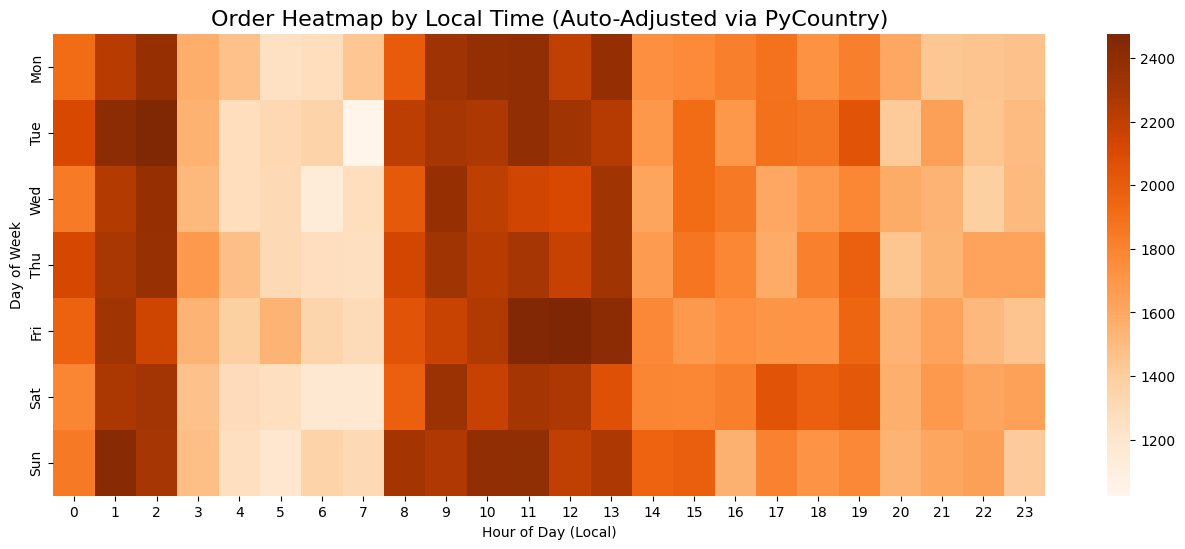

In [9]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pycountry
import pytz
from datetime import datetime

# 설정
plt.rcParams['axes.unicode_minus'] = False
DATA_DIR = "dataset"
FILE_PATH = os.path.join(DATA_DIR, 'joined', 'joined_all_users.csv')

print("Scanning data...")
lf = pl.scan_csv(FILE_PATH)

# -------------------------------------------------------
# 1. 국가별 UTC Offset 자동 계산 (Library 활용)
# -------------------------------------------------------
print("Generating Country-Timezone Mapping...")

# 데이터에 존재하는 유니크한 국가 명단 추출
unique_countries = lf.select('country').unique().collect()['country'].to_list()

country_offsets = []

for country_name in unique_countries:
    if not country_name: continue
    
    try:
        # 1. 국가 이름으로 ISO 코드 찾기 (Fuzzy Search로 'South Korea', 'Brasil' 등 처리)
        # pycountry는 'South Korea' -> 'KR', 'United States' -> 'US' 등을 찾아줍니다.
        matches = pycountry.countries.search_fuzzy(country_name)
        if not matches:
            offset = 0
        else:
            alpha_2 = matches[0].alpha_2
            
            # 2. ISO 코드로 타임존 목록 가져오기
            timezones = pytz.country_timezones.get(alpha_2, [])
            
            if timezones:
                # [Heuristic] 여러 타임존이 있는 경우(미국, 러시아 등), 
                # 가장 일반적인(첫 번째 혹은 인구 많은) 타임존을 대표로 선택합니다.
                # 예: US -> 'America/New_York'
                tz_name = timezones[0] 
                
                # 3. 현재 기준 UTC Offset 계산 (시간 단위)
                # 정확히 하려면 주문 날짜별로 DST(서머타임)를 따져야 하지만,
                # EDA 목적상 현재 기준 Offset을 적용해도 패턴 분석에는 충분합니다.
                tz = pytz.timezone(tz_name)
                now = datetime.now(tz)
                offset = now.utcoffset().total_seconds() / 3600 # 초 -> 시간 변환
            else:
                offset = 0 # 타임존 정보 없으면 UTC 유지
                
    except Exception as e:
        # 매핑 실패 시 UTC 유지 (Log만 출력)
        # print(f"Warning: Could not map '{country_name}' -> {e}")
        offset = 0
        
    country_offsets.append({"country": country_name, "utc_offset": offset})

# 매핑 테이블 생성 (DataFrame)
offset_df = pl.DataFrame(country_offsets)

print("Mapping Preview (Top 5):")
print(offset_df.head(5))

# -------------------------------------------------------
# 2. 데이터와 매핑 Join 및 Local Time 변환
# -------------------------------------------------------
# Polars에서는 컬럼마다 다른 Timezone을 가질 수 없으므로,
# Offset(시차)을 더해서 'Local Hour'를 구하는 방식이 가장 빠릅니다.

time_lf = (
    lf
    .filter(pl.col('order_id').is_not_null())
    .join(offset_df.lazy(), on='country', how='left') # Lazy Join
    .select([
        pl.col('country'),
        pl.col('utc_offset'),
        pl.col('created_at_right')
          .str.slice(0, 19)
          .str.to_datetime(format="%Y-%m-%d %H:%M:%S")
          .alias('utc_dt')
    ])
    .with_columns([
        pl.col('utc_dt').dt.hour().alias('utc_hour'),
        pl.col('utc_dt').dt.weekday().alias('weekday')
    ])
    # [핵심] Local Hour = UTC Hour + Offset
    # % 24 로 24시 넘어가는 것 처리
    .with_columns([
        ((pl.col('utc_hour') + pl.col('utc_offset').fill_null(0)) % 24).alias('local_hour')
    ])
    .group_by(['weekday', 'local_hour'])
    .agg(pl.count().alias('order_count'))
    .sort(['weekday', 'local_hour'])
)

print("Processing Local Time Data with Libraries...")
time_df = time_lf.collect().to_pandas()

# -------------------------------------------------------
# 3. 시각화 (Heatmap)
# -------------------------------------------------------
# Pivot: 행(요일) x 열(시간)
time_pivot = time_df.pivot(index='weekday', columns='local_hour', values='order_count')

# 요일 매핑
days = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
time_pivot.index = time_pivot.index.map(days)

# 컬럼 정렬 및 결측치 처리 (0~23시 강제 고정)
# float 인덱스(Offset 때문에 3.5시 등이 나올 수 있음)를 정수로 반올림/버림 처리하여 시각화 깔끔하게
time_pivot.columns = time_pivot.columns.astype(int) 
time_pivot = time_pivot.groupby(level=0, axis=1).sum() # 같은 시간대 합치기
time_pivot = time_pivot.reindex(columns=range(24)).fillna(0)

plt.figure(figsize=(16, 6))
sns.heatmap(time_pivot, cmap='Oranges', annot=False)
plt.title('Order Heatmap by Local Time (Auto-Adjusted via PyCountry)', fontsize=16)
plt.xlabel('Hour of Day (Local)')
plt.ylabel('Day of Week')
plt.show()


[4] Delivery Performance Analysis


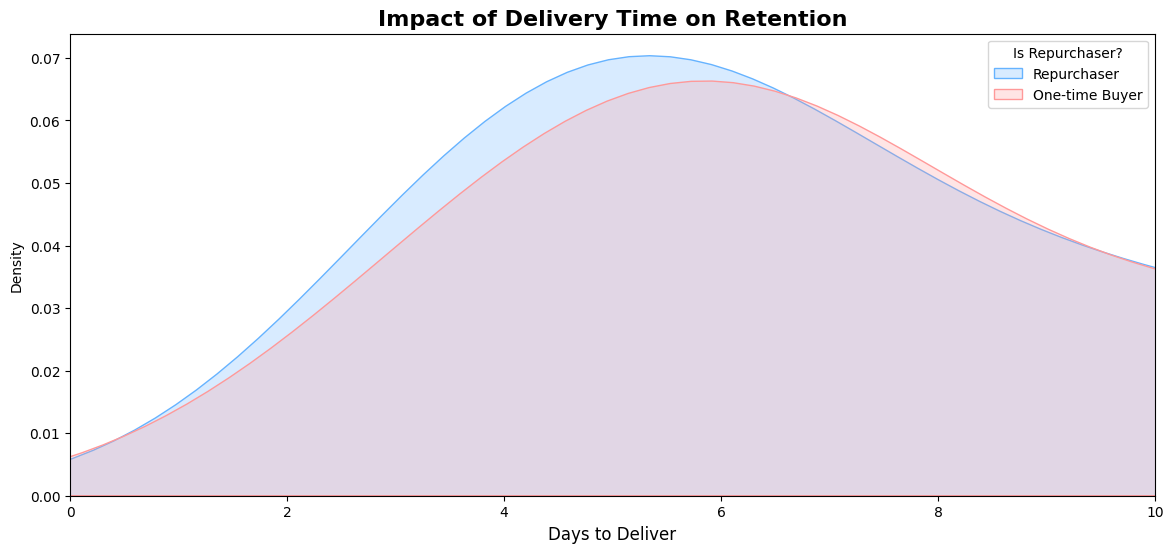

  -> Insight: 그래프가 겹쳐 있다면 배송 속도는 큰 영향이 없는 것이고,
              재구매자 그래프가 왼쪽(빠른 배송)으로 쏠려 있다면 배송 속도가 중요한 것입니다.

[5] Return Rate by Traffic Source


/var/folders/1g/n3wk5qts0l7484gylwvq_jkm0000gn/T/ipykernel_34530/2716643799.py:71: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total_orders')
/var/folders/1g/n3wk5qts0l7484gylwvq_jkm0000gn/T/ipykernel_34530/2716643799.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='return_rate', y='traffic_source', data=return_stats, palette='Reds_r')


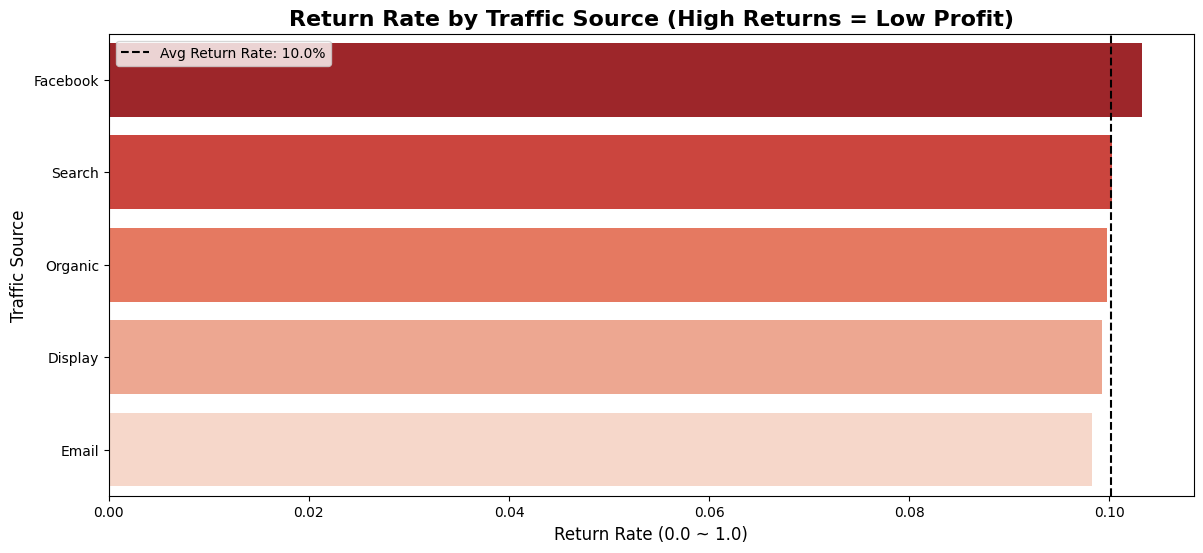

  -> Alert: 'Facebook' 채널의 반품률이 가장 높습니다.
            이 채널의 마케팅 메시지가 과장되었거나 타겟팅이 잘못되었을 수 있습니다.


In [10]:
# ... (이전 코드에 이어서) ...

# -------------------------------------------------------
# 4. [Operational Analysis] 배송 속도가 재구매에 미치는 영향
# 가설: 배송이 빠를수록 재구매율이 높을 것이다.
# -------------------------------------------------------
print("\n[4] Delivery Performance Analysis")

# 배송 기간 계산을 위한 데이터 준비
delivery_lf = (
    lf
    .filter(
        pl.col('order_id').is_not_null() & 
        pl.col('delivered_at').is_not_null() &
        pl.col('created_at_right').is_not_null()
    )
    .select([
        pl.col('user_id').cast(pl.Int64),
        
        # 날짜 파싱 (안전하게 앞부분만 잘라서)
        pl.col('created_at_right').str.slice(0, 19)
          .str.to_datetime(format="%Y-%m-%d %H:%M:%S").alias('order_date'),
        pl.col('delivered_at').str.slice(0, 19)
          .str.to_datetime(format="%Y-%m-%d %H:%M:%S").alias('delivery_date')
    ])
    .with_columns([
        # 배송 소요 시간 (일 단위)
        (pl.col('delivery_date') - pl.col('order_date')).dt.total_days().alias('days_to_deliver')
    ])
    # 이상치 제거 (배송이 0일 미만이거나 30일 넘게 걸린 건 제외)
    .filter((pl.col('days_to_deliver') >= 0) & (pl.col('days_to_deliver') <= 30))
)

# 재구매 여부 정보를 가진 buyers_pd와 결합하기 위해 Pandas로 변환 후 Merge
delivery_df = delivery_lf.collect().to_pandas()

# buyers_pd(이전 단계에서 만든 유저 등급 테이블)와 user_id로 조인
# 주의: buyers_pd는 'user_id'가 int인지 확인 필요
delivery_analysis = delivery_df.merge(buyers_pd[['user_id', 'has_repurchase']], on='user_id', how='inner')

plt.figure(figsize=(14, 6))

# 4-1. 배송 소요 시간 분포 (KDE Plot)
# 재구매 고객 vs 1회성 고객의 배송 경험 차이 비교
sns.kdeplot(data=delivery_analysis, x='days_to_deliver', hue='has_repurchase', 
            fill=True, common_norm=False, palette=['#ff9999','#66b3ff'])
plt.title('Impact of Delivery Time on Retention', fontsize=16, weight='bold')
plt.xlabel('Days to Deliver', fontsize=12)
plt.xlim(0, 10) # 대부분 10일 이내일 것이므로 줌인
plt.legend(title='Is Repurchaser?', labels=['Repurchaser', 'One-time Buyer'])
plt.show()

print("  -> Insight: 그래프가 겹쳐 있다면 배송 속도는 큰 영향이 없는 것이고,")
print("              재구매자 그래프가 왼쪽(빠른 배송)으로 쏠려 있다면 배송 속도가 중요한 것입니다.")


# -------------------------------------------------------
# 5. [Profitability Analysis] 채널별 반품률(Return Rate) 분석
# 가설: 특정 채널(예: Facebook) 유입 유저가 반품을 더 많이 할까?
# -------------------------------------------------------
print("\n[5] Return Rate by Traffic Source")

return_stats = (
    lf
    .filter(pl.col('order_id').is_not_null())
    .group_by('traffic_source')
    .agg([
        # 반품된 건수 (returned_at이 null이 아닌 경우)
        pl.col('returned_at').is_not_null().sum().alias('return_count'),
        # 전체 주문 건수
        pl.count().alias('total_orders')
    ])
    .with_columns([
        (pl.col('return_count') / pl.col('total_orders')).alias('return_rate')
    ])
    .filter(pl.col('total_orders') > 100) # 신뢰도를 위해 주문 100건 이상인 채널만
    .sort('return_rate', descending=True)
    .collect()
    .to_pandas()
)

plt.figure(figsize=(14, 6))
sns.barplot(x='return_rate', y='traffic_source', data=return_stats, palette='Reds_r')
plt.title('Return Rate by Traffic Source (High Returns = Low Profit)', fontsize=16, weight='bold')
plt.xlabel('Return Rate (0.0 ~ 1.0)', fontsize=12)
plt.ylabel('Traffic Source', fontsize=12)

# 평균 반품률 선 표시
avg_return_rate = (return_stats['return_count'].sum() / return_stats['total_orders'].sum())
plt.axvline(x=avg_return_rate, color='black', linestyle='--', label=f'Avg Return Rate: {avg_return_rate*100:.1f}%')
plt.legend()

plt.show()

print(f"  -> Alert: '{return_stats.iloc[0]['traffic_source']}' 채널의 반품률이 가장 높습니다.")
print("            이 채널의 마케팅 메시지가 과장되었거나 타겟팅이 잘못되었을 수 있습니다.")